#### LER below threshold

In [2]:
# let's try generating a threshold plot to compare thresholds of these different methods to see what should be improved / combined


# do exactly pymatching code
# check the exact logical errors from my DEM 
from clifford_deformed_cc_circuit import CDCompassCodeCircuit
from compass_code_correlated_error import CorrelatedDecoder
from pymatching import Matching
from stim import *
import numpy as np
import os
import pandas as pd

def get_circuit(d, p, l=2, eta=0.5, basis='X', CD_type="SC"):
    return CDCompassCodeCircuit(d=d, l=l, eta=eta, mem_type=basis).make_elongated_circuit_from_parity(before_measure_flip=p, 
                                                                                                    before_measure_pauli_channel=0,
                                                                                                    after_clifford_depolarization=p, 
                                                                                                    before_round_data_pauli_channel=0, 
                                                                                                    between_round_idling_pauli_channel=p, 
                                                                                                    idling_dephasing=0, 
                                                                                                    CD_type=CD_type)



def get_logical_error_rate(circuit, num_shots, decoder, basis='X', CD_type="SC"):
    sampler= circuit.compile_detector_sampler()
    dem = circuit.detector_error_model(decompose_errors=True, flatten_loops=True, approximate_disjoint_errors=True)
    dets, obs = sampler.sample(num_shots, separate_observables=True)
    matching_py_corr = Matching.from_detector_error_model(dem, enable_correlations=True)
    predictions_py_corr = matching_py_corr.decode_batch(dets, enable_correlations=True)
    num_logical_errors_py_corr = np.sum(np.any(np.array(obs) != np.array(predictions_py_corr), axis=1))
    num_logical_errors_my_corr = np.sum(decoder.decoding_failures_correlated_circuit_level(circuit, num_shots,basis, CD_type)) # not same seed, predictions or sampler so might be different
    
    return num_logical_errors_py_corr / num_shots, num_logical_errors_my_corr / num_shots

output_file = "ler_below_threshold.csv"
file_exists = os.path.isfile(output_file)
d = 9
ps = np.logspace(-2.5,-2.1, 3)
num_shots = 100_000
etas=[5]
l=2
CD_type = "ZXXZonSqu"
basis = "X"

ler_all_eta = []
ler_all_eta_corr = []
rows = []

for eta in etas:
    ler_for_ps = []
    ler_for_ps_corr = []
    for p in ps:
        circuit = get_circuit(d=d, p=p, l=l,eta=eta, basis=basis, CD_type=CD_type)
        decoder = CorrelatedDecoder(eta=eta, d=d, l=l, corr_type="CORR_XZ", mem_type=basis)
        ler_pycorr, ler_my_corr = get_logical_error_rate(
            circuit=circuit, num_shots=num_shots, decoder=decoder, basis=basis, CD_type=CD_type
        )
        ler_for_ps.append(ler_pycorr)
        ler_for_ps_corr.append(ler_my_corr)
        rows.append({
            "l": l,
            "d": d,
            "CD_type": CD_type,
            "mem_type": basis,
            "num_shots": num_shots,
            "eta": eta,
            "p": p,
            "ler_pycorr": ler_pycorr,
            "ler_my_corr": ler_my_corr
        })
    ler_all_eta.append(ler_for_ps)
    ler_all_eta_corr.append(ler_for_ps_corr)
    print(f"finished eta={eta}")

df = pd.DataFrame(rows)
df.to_csv(
    output_file,
    mode='a',    
    header=not file_exists,
    index=False
)

finished eta=5


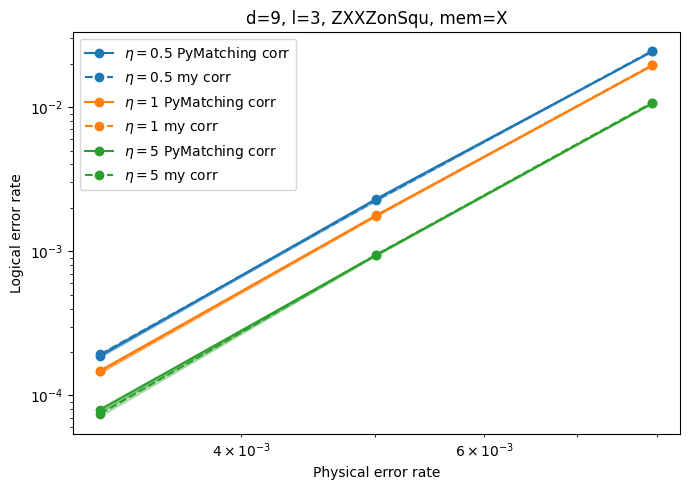

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# -------------------------
# User settings
# -------------------------
l = 3
d = 9
CD_type = "ZXXZonSqu"
mem_type = "X"
etas = [0.5,1,5]

# -------------------------
# Load aggregated data
# -------------------------
df = pd.read_csv("ler_below_threshold.csv")

df = df[
    (df["l"] == l) &
    (df["CD_type"] == CD_type) &
    (df["d"] == d) &
    (df["mem_type"] == mem_type)
].copy()

df = df.sort_values(["eta", "p"]).reset_index(drop=True)

# -------------------------
# Plot
# -------------------------
plt.figure(figsize=(7, 5))

for eta in etas:
    eta_df = df[df["eta"] == eta].sort_values("p").copy()

    if eta_df.empty:
        print(f"No data found for eta={eta}")
        continue

    ps = eta_df["p"].to_numpy()
    lers_py = eta_df["ler_pycorr"].to_numpy()
    lers_my = eta_df["ler_my_corr"].to_numpy()
    total_shots = eta_df["total_shots"].to_numpy()

    # Binomial standard errors
    sterr_py = np.sqrt(lers_py / total_shots)
    sterr_my = np.sqrt(lers_my / total_shots)

    line, = plt.plot(
        ps,
        lers_py,
        marker="o",
        label=f"$\\eta={eta}$ PyMatching corr"
    )
    color = line.get_color()

    plt.plot(
        ps,
        lers_my,
        "--",
        marker="o",
        color=color,
        label=f"$\\eta={eta}$ my corr"
    )

    plt.fill_between(
        ps,
        lers_py - sterr_py,
        lers_py + sterr_py,
        color=color,
        alpha=0.30
    )

    plt.fill_between(
        ps,
        lers_my - sterr_my,
        lers_my + sterr_my,
        color=color,
        alpha=0.30
    )

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Physical error rate")
plt.ylabel("Logical error rate")
plt.title(f"d={d}, l={l}, {CD_type}, mem={mem_type}")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

#### Signed gap histograms figure

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colormaps
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


def plot_signed_gap_hist_2x2_by_eta_with_mean_inset(
    df,
    d=None,
    p=None,
    mem_type=None,
    l_values=(2, 4),
    cd_types=("SC", "ZXXZonSqu"),
    eta_values=None,
    decoder_order=("PY_CORR", "MWPM"),
    bins=120,
    density=False,
    log_y=True,
    figsize=(13, 10),
    suptitle=None,
    inset_loc="upper left",
    inset_width="32%",
    inset_height="23%",
    inset_pad_frac=0.25,
):
    """
    2x2 grid of signed-gap histograms.

    Main axes:
      - full hump histograms
      - color determined by eta (plasma)
      - PY_CORR and MWPM use same color, different opacity
      - vertical lines at means

    Inset:
      - shows ONLY the mean locations
      - specifically highlights the PY_CORR vs MWPM separation
    """

    plot_df = df.copy()

    if d is not None:
        plot_df = plot_df[plot_df["d"] == d]
    if p is not None:
        plot_df = plot_df[np.isclose(plot_df["p"], p)]
    if mem_type is not None:
        plot_df = plot_df[plot_df["mem_type"] == mem_type]

    if eta_values is None:
        eta_values = sorted(plot_df["eta"].dropna().unique())
    else:
        eta_values = list(eta_values)

    plot_df = plot_df[
        plot_df["decoder_type"].isin(decoder_order) &
        plot_df["eta"].isin(eta_values)
    ]

    cmap = colormaps["plasma"]
    if len(eta_values) == 1:
        eta_to_color = {eta_values[0]: cmap(0.7)}
    else:
        eta_to_color = {
            eta: cmap(i / (len(eta_values) - 1))
            for i, eta in enumerate(eta_values)
        }

    decoder_style = {
        "PY_CORR": {
            "label": "corr_py",
            "fill_alpha": 0.34,
            "line_alpha": 0.45,
            "mean_ls": "--",
            "mean_lw": 2.0,
        },
        "MWPM": {
            "label": "mwpm",
            "fill_alpha": 0.16,
            "line_alpha": 0.30,
            "mean_ls": ":",
            "mean_lw": 2.2,
        },
    }

    fig, axes = plt.subplots(2, 2, figsize=figsize, sharex=False, sharey=False)
    axes = np.array(axes)
    panel_labels = ["(a)", "(b)", "(c)", "(d)"]

    for i, l_val in enumerate(l_values):
        for j, cd_type in enumerate(cd_types):
            ax = axes[i, j]
            panel_idx = i * 2 + j

            subdf = plot_df[
                (plot_df["l"] == l_val) &
                (plot_df["CD_type"] == cd_type)
            ]

            if subdf.empty:
                ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
                ax.set_title(f"{panel_labels[panel_idx]}  $l={l_val}$, {cd_type}")
                continue

            x = subdf["signed_gap"].dropna().values
            if len(x) == 0:
                ax.text(0.5, 0.5, "No signed_gap data", ha="center", va="center", transform=ax.transAxes)
                ax.set_title(f"{panel_labels[panel_idx]}  $l={l_val}$, {cd_type}")
                continue

            bin_edges = np.histogram_bin_edges(x, bins=bins)

            # store pairwise means by eta
            mean_pairs = {}

            for eta in eta_values:
                eta_df = subdf[subdf["eta"] == eta]
                if eta_df.empty:
                    continue

                color = eta_to_color[eta]
                mean_pairs[eta] = {}

                for decoder in decoder_order:
                    dec_df = eta_df[eta_df["decoder_type"] == decoder]
                    vals = dec_df["signed_gap"].dropna().values
                    if len(vals) == 0:
                        continue

                    style = decoder_style[decoder]
                    legend_label = f"$\\eta={eta}$" if decoder == decoder_order[0] else None

                    # main histogram
                    ax.hist(
                        vals,
                        bins=bin_edges,
                        density=density,
                        histtype="stepfilled",
                        color=color,
                        alpha=style["fill_alpha"],
                        label=legend_label,
                    )

                    ax.hist(
                        vals,
                        bins=bin_edges,
                        density=density,
                        histtype="step",
                        color=color,
                        alpha=style["line_alpha"],
                        linewidth=0.9,
                    )

                    mean_val = np.mean(vals)
                    mean_pairs[eta][decoder] = mean_val

                    ax.axvline(
                        mean_val,
                        color=color,
                        linestyle=style["mean_ls"],
                        linewidth=style["mean_lw"],
                        alpha=0.95,
                    )

            ax.set_title(f"{panel_labels[panel_idx]}  $l={l_val}$, {cd_type}", fontsize=11)
            ax.set_xlabel("Complementary gap [dB]")
            ax.set_ylabel("Density" if density else "Unnormalized counts")
            ax.grid(alpha=0.22)

            if log_y:
                ax.set_yscale("log")

            # ----- inset showing pairwise PY_CORR vs MWPM mean differences -----
            valid_mean_pairs = {
                eta: pair for eta, pair in mean_pairs.items()
                if "PY_CORR" in pair and "MWPM" in pair
            }

            if len(valid_mean_pairs) > 0:
                axins = inset_axes(
                    ax,
                    width=inset_width,
                    height=inset_height,
                    loc=inset_loc,
                    borderpad=1.0
                )

                all_pair_means = []
                y_positions = np.arange(len(valid_mean_pairs), 0, -1)

                for y, eta in zip(y_positions, valid_mean_pairs.keys()):
                    color = eta_to_color[eta]
                    py_mean = valid_mean_pairs[eta]["PY_CORR"]
                    mwpm_mean = valid_mean_pairs[eta]["MWPM"]

                    all_pair_means.extend([py_mean, mwpm_mean])

                    # faint connector between the two means
                    axins.plot(
                        [py_mean, mwpm_mean], [y, y],
                        color=color,
                        alpha=0.35,
                        linewidth=1.2
                    )

                    # PY_CORR mean
                    axins.axvline(
                        py_mean,
                        ymin=(y - 0.35) / (len(y_positions) + 0.5),
                        ymax=(y + 0.35) / (len(y_positions) + 0.5),
                        color=color,
                        linestyle=decoder_style["PY_CORR"]["mean_ls"],
                        linewidth=1.6,
                        alpha=0.95,
                    )

                    # MWPM mean
                    axins.axvline(
                        mwpm_mean,
                        ymin=(y - 0.35) / (len(y_positions) + 0.5),
                        ymax=(y + 0.35) / (len(y_positions) + 0.5),
                        color=color,
                        linestyle=decoder_style["MWPM"]["mean_ls"],
                        linewidth=1.8,
                        alpha=0.95,
                    )

                xmin = min(all_pair_means)
                xmax = max(all_pair_means)
                spread = xmax - xmin
                if spread == 0:
                    spread = 1.0
                pad = inset_pad_frac * spread

                axins.set_xlim(xmin - pad, xmax + pad)
                axins.set_ylim(0.5, len(y_positions) + 0.5)
                axins.set_yticks([])
                axins.set_title("Mean zoom", fontsize=8, pad=2)
                axins.tick_params(axis="x", labelsize=8)
                axins.grid(alpha=0.15)

                # optional: label eta rows inside inset
                for y, eta in zip(y_positions, valid_mean_pairs.keys()):
                    axins.text(
                        0.02, y,
                        f"$\\eta={eta}$",
                        transform=axins.get_yaxis_transform(),
                        ha="left", va="center",
                        fontsize=7
                    )

    handles, labels = axes[0, 0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="upper center", ncol=min(len(labels), 4), frameon=False)

    fig.text(
        0.5,
        0.93,
        "Dashed = corr_py mean, dotted = mwpm mean; same color = same $\\eta$",
        ha="center",
        fontsize=10
    )

    if suptitle is None:
        parts = []
        if d is not None:
            parts.append(f"d={d}")
        if p is not None:
            parts.append(f"p={p}")
        if mem_type is not None:
            parts.append(f"mem_type={mem_type}")

        suptitle = "Complementary gap histograms"
        if parts:
            suptitle += " (" + ", ".join(parts) + ")"

    fig.suptitle(suptitle, y=0.975, fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.90])
    plt.show()

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colormaps
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.lines import Line2D


def plot_signed_gap_hist_2x2_by_eta_with_single_eta_inset(
    df,
    d=None,
    p=None,
    mem_type=None,
    l_values=(2, 4),
    cd_types=("SC", "ZXXZonSqu"),
    eta_values=None,
    decoder_order=("PY_CORR", "MWPM"),
    inset_eta=None,
    bins=120,
    density=False,
    log_y=True,
    figsize=(13, 10),
    suptitle=None,
    inset_loc="upper left",
    inset_width="26%",
    inset_height="20%",
    inset_pad_frac=0.25,   # tighter zoom than before
    inset_min_width=0.12,  # tighter minimum width in dB
):
    """
    2x2 grid of signed-gap histograms.

    Main axes:
      - full hump histograms for all eta values
      - color determined by eta
      - PY_CORR and MWPM use same color, different opacity / line style
      - vertical lines at means

    Inset:
      - shows one chosen eta
      - contrasts PY_CORR vs MWPM means on a tightly zoomed x-scale
      - annotates Delta and variances
    """

    plot_df = df.copy()

    if d is not None:
        plot_df = plot_df[plot_df["d"] == d]
    if p is not None:
        plot_df = plot_df[np.isclose(plot_df["p"], p)]
    if mem_type is not None:
        plot_df = plot_df[plot_df["mem_type"] == mem_type]

    if eta_values is None:
        eta_values = sorted(plot_df["eta"].dropna().unique())
    else:
        eta_values = list(eta_values)

    plot_df = plot_df[
        plot_df["decoder_type"].isin(decoder_order) &
        plot_df["eta"].isin(eta_values)
    ]

    if inset_eta is None:
        inset_eta = eta_values[-1]

    cd_type_labels = {
        "SC": "CSS",
        "ZXXZonSqu": "ZXXZ\u25A1",
    }

    cmap = colormaps["plasma"]

    # purple -> orange, avoid bright yellow end
    def truncated_cmap(x):
        return cmap(0.05 + 0.65 * x)

    if len(eta_values) == 1:
        eta_to_color = {eta_values[0]: truncated_cmap(0.8)}
    else:
        eta_to_color = {
            eta: truncated_cmap(i / (len(eta_values) - 1))
            for i, eta in enumerate(eta_values)
        }

    decoder_style = {
        "PY_CORR": {
            "label": "corr_py",
            "fill_alpha": 0.34,
            "line_alpha": 0.45,
            "mean_ls": "--",
            "mean_lw": 2.0,
        },
        "MWPM": {
            "label": "mwpm",
            "fill_alpha": 0.16,
            "line_alpha": 0.30,
            "mean_ls": "-",
            "mean_lw": 2.2,
        },
    }

    fig, axes = plt.subplots(2, 2, figsize=figsize, sharex=True, sharey=True)
    axes = np.array(axes)
    panel_labels = ["(a)", "(b)", "(c)", "(d)"]

    for i, l_val in enumerate(l_values):
        for j, cd_type in enumerate(cd_types):
            ax = axes[i, j]
            panel_idx = i * 2 + j
            cd_type_display = cd_type_labels.get(cd_type, cd_type)

            subdf = plot_df[
                (plot_df["l"] == l_val) &
                (plot_df["CD_type"] == cd_type)
            ]

            if subdf.empty:
                ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
                ax.set_title(f"{panel_labels[panel_idx]} $l={l_val}$, {cd_type_display}", fontsize=13)
                continue

            x = subdf["signed_gap"].dropna().values
            if len(x) == 0:
                ax.text(0.5, 0.5, "No signed_gap data", ha="center", va="center", transform=ax.transAxes)
                ax.set_title(f"{panel_labels[panel_idx]} $l={l_val}$, {cd_type_display}", fontsize=13)
                continue

            bin_edges = np.histogram_bin_edges(x, bins=bins)
            stats_by_eta = {}

            for eta in eta_values:
                eta_df = subdf[subdf["eta"] == eta]
                if eta_df.empty:
                    continue

                color = eta_to_color[eta]
                stats_by_eta[eta] = {}

                for decoder in decoder_order:
                    dec_df = eta_df[eta_df["decoder_type"] == decoder]
                    vals = dec_df["signed_gap"].dropna().values
                    if len(vals) == 0:
                        continue

                    style = decoder_style[decoder]
                    legend_label = f"$\\eta={eta}$" if decoder == decoder_order[0] else None

                    ax.hist(
                        vals,
                        bins=bin_edges,
                        density=density,
                        histtype="stepfilled",
                        color=color,
                        alpha=style["fill_alpha"],
                        label=legend_label,
                    )

                    ax.hist(
                        vals,
                        bins=bin_edges,
                        density=density,
                        histtype="step",
                        color=color,
                        alpha=style["line_alpha"],
                        linewidth=0.9,
                    )

                    mean_val = np.mean(vals)
                    std_val = np.std(vals, ddof=1) if len(vals) > 1 else 0.0

                    stats_by_eta[eta][decoder] = {
                        "mean": mean_val,
                        "std": std_val,
                    }

                    ax.axvline(
                        mean_val,
                        color=color,
                        linestyle=style["mean_ls"],
                        linewidth=style["mean_lw"],
                        alpha=0.95,
                    )

            ax.set_title(
                f"{panel_labels[panel_idx]} $l={l_val}$, {cd_type_display}",
                fontsize=13
            )
            ax.grid(alpha=0.22)

            if log_y:
                ax.set_yscale("log")

            # inset for one selected eta only
            if (
                inset_eta in stats_by_eta and
                "PY_CORR" in stats_by_eta[inset_eta] and
                "MWPM" in stats_by_eta[inset_eta]
            ):
                py_mean = stats_by_eta[inset_eta]["PY_CORR"]["mean"]
                mwpm_mean = stats_by_eta[inset_eta]["MWPM"]["mean"]
                py_std = stats_by_eta[inset_eta]["PY_CORR"]["std"]
                mwpm_std = stats_by_eta[inset_eta]["MWPM"]["std"]
                color = eta_to_color[inset_eta]

                delta = py_mean - mwpm_mean

                axins = inset_axes(
                    ax,
                    width=inset_width,
                    height=inset_height,
                    loc=inset_loc,
                    borderpad=1.0
                )

                xmin = min(py_mean, mwpm_mean)
                xmax = max(py_mean, mwpm_mean)
                spread = xmax - xmin

                if spread < inset_min_width:
                    center = 0.5 * (xmin + xmax)
                    half_width = 0.5 * inset_min_width
                    x1 = center - half_width
                    x2 = center + half_width
                else:
                    pad = inset_pad_frac * spread
                    x1 = xmin - pad
                    x2 = xmax + pad

                # connector line only
                axins.plot(
                    [py_mean, mwpm_mean], [0.5, 0.5],
                    color=color,
                    alpha=0.35,
                    linewidth=1.0
                )

                # mean lines
                axins.axvline(
                    py_mean,
                    color=color,
                    linestyle=decoder_style["PY_CORR"]["mean_ls"],
                    linewidth=1.6,
                    alpha=0.95,
                )
                axins.axvline(
                    mwpm_mean,
                    color=color,
                    linestyle=decoder_style["MWPM"]["mean_ls"],
                    linewidth=1.8,
                    alpha=0.95,
                )

                # annotate without arrows
                mid_x = 0.5 * (py_mean + mwpm_mean)

                axins.text(
                    mid_x,
                    0.78,
                    rf"$\Delta_{{\mu}}={delta:.2f}\,\mathrm{{dB}}$",
                    ha="center",
                    va="center",
                    fontsize=8,
                    color="black"
                )

                axins.text(
                    mid_x,
                    0.60,
                    rf"$\sigma_{{\rm corr}}={py_std:.2f}$",
                    ha="center",
                    va="center",
                    fontsize=7,
                    color="black"
                )

                axins.text(
                    mid_x,
                    0.44,
                    rf"$\sigma_{{\rm MWPM}}={mwpm_std:.2f}$",
                    ha="center",
                    va="center",
                    fontsize=7,
                    color="black"
                )

                axins.set_xlim(x1, x2)
                axins.set_ylim(0.25, 0.92)
                axins.set_yticks([])
                axins.set_title(f"Zoom: $\\eta={inset_eta}$", fontsize=8, pad=2)
                axins.tick_params(axis="x", labelsize=8)
                axins.grid(alpha=0.15)

    # eta legend
    handles, labels = axes[0, 0].get_legend_handles_labels()
    if handles:
        fig.legend(
            handles,
            labels,
            loc="upper center",
            bbox_to_anchor=(0.5, 0.985),
            ncol=min(len(labels), 4),
            frameon=False,
            fontsize=12
        )

    # line style legend
    line_handles = [
        Line2D([0], [0],
               color="black",
               linestyle=decoder_style["PY_CORR"]["mean_ls"],
               linewidth=2,
               label="CORR$_{py}$"),
        Line2D([0], [0],
               color="black",
               linestyle=decoder_style["MWPM"]["mean_ls"],
               linewidth=2,
               label="MWPM"),
    ]

    fig.legend(
        handles=line_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.94),
        ncol=2,
        frameon=False,
        fontsize=12
    )

    if suptitle is None:
        title_line = "Signed Complementary Gap Distributions"

        subtitle_parts = []
        if d is not None:
            subtitle_parts.append(f"$d={d}$")
        if p is not None:
            subtitle_parts.append(f"$p={p}$")
        if mem_type is not None:
            subtitle_parts.append(f"memory type $={mem_type}$")

        if subtitle_parts:
            suptitle = title_line + "\n" + ", ".join(subtitle_parts)
        else:
            suptitle = title_line

    # Uncomment if you want the overall title back
    # fig.suptitle(suptitle, y=1.02, fontsize=18)

    # overall axis labels only
    fig.supxlabel("Complementary gap [dB]", fontsize=14, y=0.04)
    fig.supylabel("Unnormalized counts" if not density else "Density", fontsize=14, x=0.04)

    fig.tight_layout(rect=[0.05, 0.06, 1, 0.90])
    plt.show()

/var/folders/m6/1pcn_m250l175cmxwtstjnxh0000gn/T/ipykernel_26590/3416113613.py:353: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0.05, 0.06, 1, 0.90])


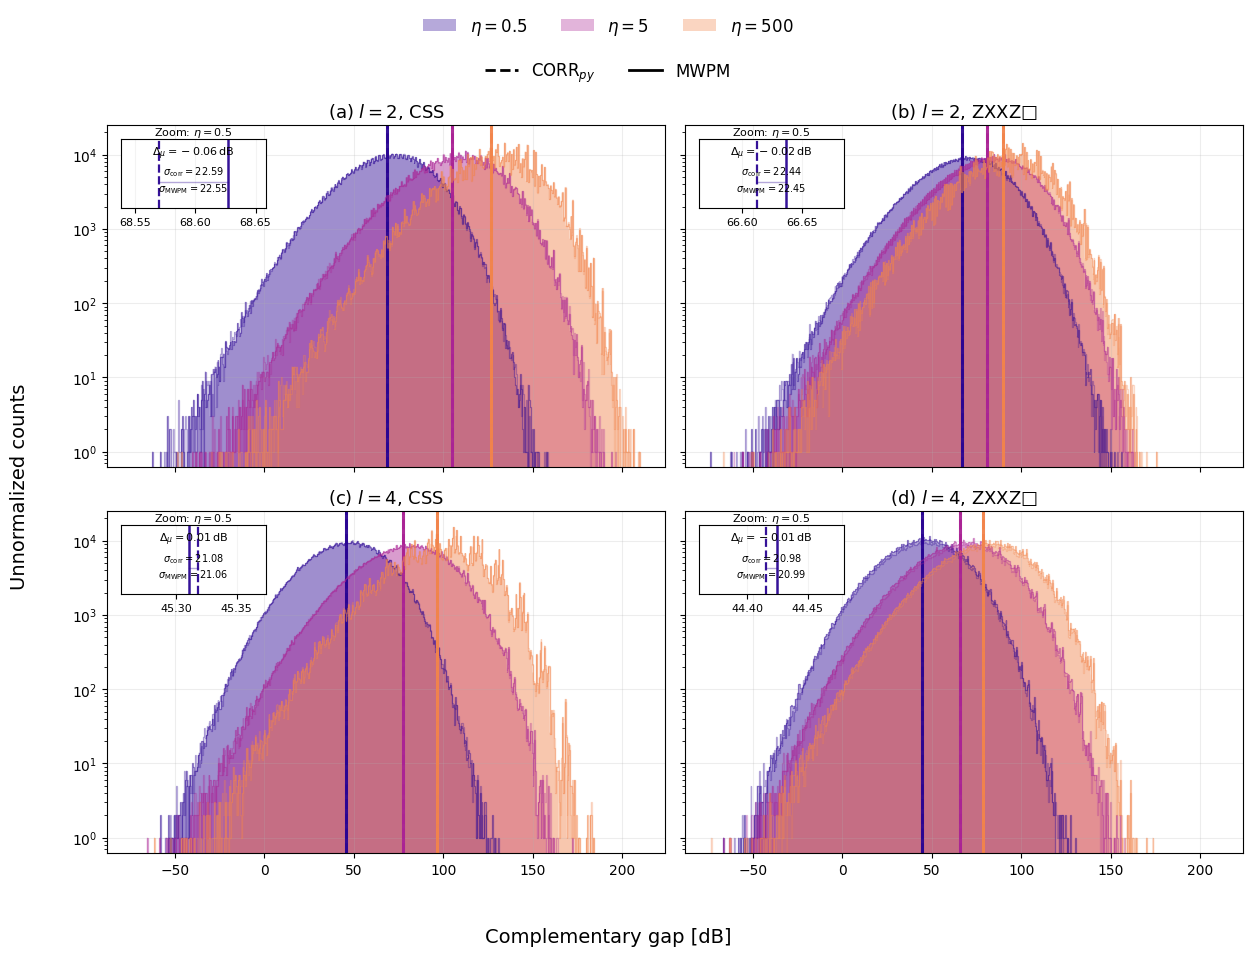

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

df = pd.read_csv("signed_gap_data.csv")


plot_signed_gap_hist_2x2_by_eta_with_single_eta_inset(
    df,
    d=11,
    p=0.005,
    mem_type="Z",
    l_values=(2, 4),
    cd_types=("SC", "ZXXZonSqu"),
    eta_values=[0.5, 5, 500],
    inset_eta=0.5,
    bins=500,
    density=False,
    log_y=True
)